In [1]:
import cell2mol
import numpy as np
import os

In [2]:
# infopath = "BACZUB/BACZUB.info"
infopath = "INOVAL/INOVAL.info"

In [3]:
from cell2mol.read_write import readinfo
from cell2mol.classes import cell
from cell2mol.cell_reconstruction import classify_fragments, fragments_reconstruct
from cell2mol.charge_assignment import *

In [4]:
name = "INOVAL"

In [5]:
debug=2

In [6]:
print(f"INITIATING cell object from input") 

# Reads reference molecules from info file, as well as labels and coordinates
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
# Initiates cell
newcell = cell(name, labels, pos, cellvec, cellparam)
# # Loads the reference molecules and checks_missing_H
# # TODO : reconstruct the unit cell without using reference molecules
# # TODO : reconstruct the unit cell using (only reconstruction of) reference molecules and Space group
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=debug) 
newcell.assess_errors()
# newcell.save(ref_cell_fname)
# ######################
# ### CALLS CELL2MOL ###
# ######################
# print(f"ENTERING cell2mol with debug={debug}")
# cell = cell2mol(newcell, reconstruction=True, charge_assignment=True, spin_assignment=True, debug=debug)
# cell.assess_errors()
# cell.save(cell_fname)

INITIATING cell object from input
MOLECULE.SPLIT COMPLEX: labels=['Fe', 'Cl', 'Cl', 'Cl', 'O', 'H', 'H']
MOLECULE.SPLIT COMPLEX: metal_idx=[0]
MOLECULE.SPLIT COMPLEX: rest_idx=[1, 2, 3, 4, 5, 6]
SPLIT COMPLEX: rest labels: ['Cl', 'Cl', 'Cl', 'O', 'H', 'H']
SPLIT COMPLEX: rest coord: [[4.8139984268383635, 1.1805652875553925, 3.333073124178108], [7.250636970581888, 1.62258466795451, 0.45999712960445105], [4.856882530390316, 4.427793920077216, 1.030069539186763], [3.7025349960199416, 1.3810959182656035, 0.13850742300244523], [3.879901531654197, 0.5498751049594834, -0.0380260058105337], [2.9430798919008274, 1.49644435785722, 0.4002737453740389]]
SPLIT COMPLEX: rest indices: [1, 2, 3, 4, 5, 6]
SPLIT COMPLEX: rest radii: [1.02, 1.02, 1.02, 0.66, 0.31, 0.31]
SPLIT COMPLEX: splitting species with 6 atoms in block
labels=['Cl', 'Cl', 'Cl', 'O', 'H', 'H'] 6
indices=None
SPLIT COMPLEX: received 4 blocks
PREPARING BLOCK: [3, 4, 5]
CREATING LIGAND: H2-O
PREPARING BLOCK: [2]
CREATING LIGAND: Cl
PREP

In [7]:
mol = newcell.refmoleclist[0]
print(mol)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 7
 Formula                      = H2-O-Cl3-Fe
 Has Adjacency Matrix         = YES
 Number of Ligands            = 4
 Number of Metals             = 1
---------------------------------------------------



In [8]:
lig = mol.ligands[0]
print(lig)

------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 3
 Formula                      = H2-O
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
 Number of Groups             = 1
---------------------------------------------------



In [9]:
for lig in mol.ligands:
    for gr in lig.groups:
        print(gr) 

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = O
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 

In [10]:
newcell.assess_errors()

In [11]:
newcell.has_isolated_H

False

In [12]:
newcell.check_missing_H(debug=debug)                                     


##################
Checking Missing H
##################
Not a Single Molecule has Missing H atoms (apparently)


False

In [13]:
newcell.has_missing_H

False

In [14]:
newcell.reconstruct(debug=debug) 

CLASSIFY_FRAGMENTS. 39 Blocks sorted as (Molec, Frag, H): 1 22 16

##############################################
FRAG_RECONSTRUCT. 22 molecules submitted to SEQUENTIAL with Heavy
##############################################
FRAG_RECONSTRUCT. 0 molecules and 8 fragments out of SEQUENTIAL with Heavy
FRAG_RECONSTRUCT. 24 molecules submitted to sequential with All
FINISHED succesfully
FRAG_RECONSTRUCT. No remaining Molecules after Hydrogen reconstruction
MOLECULE.SPLIT COMPLEX: labels=['Fe', 'Fe', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl']
MOLECULE.SPLIT COMPLEX: metal_idx=[0, 1]
MOLECULE.SPLIT COMPLEX: rest_idx=[2, 3, 4, 5, 6, 7]
SPLIT COMPLEX: rest labels: ['Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl']
SPLIT COMPLEX: rest coord: [[8.504325, 4.9441406, 8.6069974], [12.3534909, 10.2389616, 7.2768814], [10.0814801, 8.2617062, 9.5185732], [10.7763357, 6.921396, 6.3653056], [7.4116689, 8.4886261, 6.9897009], [13.4461469, 6.6944761, 8.8941779]]
SPLIT COMPLEX: rest indices: [2, 3, 4, 5, 6, 7]
SPLIT COMPLEX: 

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Fe2
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H10-C4-O
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type    

In [15]:
newcell.error_reconstruction

False

In [16]:
newcell.is_fragmented

False

In [17]:
newcell.get_unique_species(debug=0)

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 1
  Formula                      = Cl
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 5
  Regular Adjacencies (connec) = 5
  Coordination Sphere Formula  = Cl4-Fe
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number 

In [18]:
print(newcell.moleclist[0].get_protonation_states())

LIGAND.SPLIT_LIGAND: self.indices=[0]
LIGAND.SPLIT_LIGAND: conn_idx=[0]
LIGAND.SPLIT_LIGAND: conn_labels=['Cl']
LIGAND.SPLIT_LIGAND: conn_coord=[[13.4461469, 6.6944761, 8.8941779]]
LIGAND.SPLIT_LIGAND: conn_radii=[1.02]
blocklist=[[0]]
LIGAND.SPLIT_LIGAND: block=[0]
LIGAND.SPLIT_LIGAND: self.indices=[0]
LIGAND.SPLIT_LIGAND: conn_idx=[0]
LIGAND.SPLIT_LIGAND: conn_labels=['Cl']
LIGAND.SPLIT_LIGAND: conn_coord=[[7.4116689, 8.4886261, 6.9897009]]
LIGAND.SPLIT_LIGAND: conn_radii=[1.02]
blocklist=[[0]]
LIGAND.SPLIT_LIGAND: block=[0]
LIGAND.SPLIT_LIGAND: self.indices=[0]
LIGAND.SPLIT_LIGAND: conn_idx=[0]
LIGAND.SPLIT_LIGAND: conn_labels=['Cl']
LIGAND.SPLIT_LIGAND: conn_coord=[[10.7763357, 6.921396, 6.3653056]]
LIGAND.SPLIT_LIGAND: conn_radii=[1.02]
blocklist=[[0]]
LIGAND.SPLIT_LIGAND: block=[0]
LIGAND.SPLIT_LIGAND: self.indices=[0]
LIGAND.SPLIT_LIGAND: conn_idx=[0]
LIGAND.SPLIT_LIGAND: conn_labels=['Cl']
LIGAND.SPLIT_LIGAND: conn_coord=[[10.0814801, 8.2617062, 9.5185732]]
LIGAND.SPLIT_LIGAND:

In [126]:
selected_cs = []
for idx, spec in enumerate(newcell.unique_species):
#     print("doing", spec)
    if spec.subtype != "metal":
        spec.get_protonation_states()
        spec.get_possible_cs()
        print(spec.formula)
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
        print(f"{spec.protonation_states=}")
        for prot in spec.protonation_states :
             for sub_spec, sub_prot in zip(spec.coord, prot.coords):
                print(sub_spec, sub_prot, (sub_spec == sub_prot)) 
        print("==========")     
        for cs in spec.possible_cs :
             for sub_spec, sub_cs_prot in zip(spec.coord, cs.protonation.coords):
                print(sub_spec, sub_cs_prot, (sub_spec == sub_cs_prot))     
                
        print("==========")     
        for prot, cs in  zip(spec.protonation_states, spec.possible_cs) :
             for sub_prot, sub_cs_prot in zip(prot.coords, cs.protonation.coords):
                print(sub_prot, sub_cs_prot, (sub_prot == sub_cs_prot))   
    else :
        spec.get_possible_cs()
        selected_cs.append(spec.possible_cs)   
    print("")
print(selected_cs)

protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['Cl']
 Atoms added in positions        = [0]
 Atoms blocked (no atoms added)  = [1]
---------------------------------------------------
]
smiles='[Cl-]'
smiles='[Cl-]'
smiles='[Cl-]'
smiles='[Cl-]'
smiles='[Cl-]'
Cl
spec.protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['Cl']
 Atoms added in positions        = [0]
 Atoms blocked (no atoms added)  = [1]
---------------------------------------------------
]
[13.4461469, 6.6944761, 8.8941779] [13.4461469, 6.6944761, 8.8941779] True
[13.4461469, 6.6944761, 8.8941779] [13.4461469, 6.6944761, 8.8941779] True
[13.4461469, 6.6944761, 8.8941779] [13.4461469, 6.6944761, 8.8941779] True


CREATED EMPTY PROTONATION ------------- Cell2mol Protonation ----------------
 Status                          = True


In [61]:
for idx, spec in enumerate(newcell.unique_species):
    if spec.subtype != "metal": print(idx, spec.possible_cs[0].protonation)

0 ------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['Cl']
 Atoms added in positions        = [0]
 Atoms blocked (no atoms added)  = [1]
---------------------------------------------------

2 ------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['C', 'H', 'H', 'C', 'H', 'H', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'H', 'H']
 Atoms added in positions        = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Atoms blocked (no atoms added)  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
---------------------------------------------------

3 ------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'H', 'H']
 Atoms added in positions        = [0 0 0]
 Atoms blocked (no atoms added)  = [1 0 0]
---------------------------------------------------

5 ------------- Cell2mol Prot

In [104]:
final_charge_distribution = balance_charge(newcell.unique_indices, newcell.unique_species, debug=2)

BALANCE: iterlist [[-1], [2, 3], [0], [0], [2, 3], [1]]
BALANCE: unique_indices [0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 0, 0, 0, 4, 2, 3, 0, 0, 0, 4, 5, 5, 5, 5]
BALANCE: tmpdistr [(-1, 2, 0, 0, 2, 1), (-1, 2, 0, 0, 3, 1), (-1, 3, 0, 0, 2, 1), (-1, 3, 0, 0, 3, 1)]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 3, 0, 0, -1, -1, -1, 3, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 3, 0, 0, -1, -1, -1, 3, 1, 1, 1, 1]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 3, 3, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 3, 0, 0, -1, -1

In [63]:
final_charge_distribution

[[-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  2,
  2,
  0,
  0,
  -1,
  -1,
  -1,
  2,
  0,
  0,
  -1,
  -1,
  -1,
  2,
  1,
  1,
  1,
  1]]

In [27]:
selected_cs

[[-1], [2, 3], [0], [0], [2, 3], [1]]

In [42]:
newcell.moleclist, newcell.error_prepare_mols = prepare_mols(newcell.moleclist, 
                                                             newcell.unique_indices, 
                                                             newcell.unique_species, 
                                                             selected_cs, 
                                                             final_charge_distribution[0], 
                                                             debug=debug)


******************idx=0 mol.formula='Cl6-Fe2'******************
PREPARE: Molecule 0 has 6 ligands

PREPARE: Doing Ligand 0 with unique_index: 0
PREPARE: Ligand 
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Total Charge                 = -1
 Smiles                       = [Cl-]
 Origin                       = split_complex
 Number of Groups             = 1
---------------------------------------------------

PREPARE: Match with unique specie 
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Total Charge                 = -1
 Smiles              

In [31]:
newcell.create_bonds(debug=debug)

CELL.CREATE_BONDS: Creating Bonds for molecule Cl6-Fe2
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
CELL.CREATE_BONDS: Creating Metal-Metal Bonds for molecule Cl6-Fe2
CELL.CREATE_BONDS: Metals: [------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 5
 Regular Adjacencies (connec) = 5
 Atom Charge                  = 2.0
 Coordination Sphere Formula  = Cl4-Fe
 Possible Charges             = [2, 3]
----------------------------------------------------
, ------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Numb

AttributeError: 'NoneType' object has no attribute 'append'

In [ ]:
newcell.unique_species[5].labels[:10]

In [ ]:
newcell.moleclist[8].rdkit_obj

In [ ]:
newcell.moleclist

In [ ]:
for i, mol in enumerate(newcell.moleclist):
    print(i, mol.formula, mol.iscomplex)
#     if not mol.iscomplex:
    
# #         try :
# #             print(mol.possible_cs)
# #         except:
# #             print("No possible_cs assigned", mol.formula)
# #         try :
# #             print(mol.protonation_states)
# #         except:
# #             print("No protonation_states assigned", mol.formula)
#         try :
#             print(mol.rdkit_obj)
#         except:
#             print("No protonation_states assigned", mol.rdkit_obj)
#             Draw.MolsToGridImage(mol.rdkit_obj)
# #     else :
# #         for lig in mol.ligands:
# # #             try :
# # #                 print(lig.possible_cs)
# # #             except:
# # #                 print("No possible_cs assigned", lig.formula)
                
# #             try :
# #                 print(lig.protonation_states)
#             except:
#                 print("No protonation_states assigned", lig.formula)
# #         for met in mol.metals:
# #             try :
# #                 print(met.possible_cs)
# #             except:
# #                 print("No possible_cs assigned", met.label)

In [ ]:
for lig in newcell.moleclist[4].ligands:
    display(lig.rdkit_obj)

In [ ]:
newcell.moleclist[3].rdkit_obj

In [ ]:
newcell.moleclist[8].rdkit_obj

In [ ]:
from cell2mol.connectivity import *


In [ ]:
final_charge_distribution, newcell.unique_indices

In [ ]:
newcell.unique_species

In [ ]:
newcell.unique_species

In [ ]:
newcell.moleclist

In [ ]:
from cell2mol.hungarian import reorder

In [ ]:
np.where()

In [ ]:
newcell.unique_indices

In [ ]:
count = 0
for idx, mol in enumerate(newcell.moleclist):
    print(mol.formula)
    if mol.subtype == "molecule" and mol.iscomplex == False:
        print(idx, mol.formula, mol.unique_index)
        count += 1
    elif mol.iscomplex :
        for jdx, lig in enumerate(mol.ligands):
            print(idx, jdx, lig.formula, lig.unique_index)
            count += 1
        for jdx, met in enumerate(mol.metals):
            print(idx, jdx, met.label, met.unique_index)
            count += 1
    print("")
print(count)

In [ ]:
type(final_charge_distribution)

In [ ]:
help(cs)

In [ ]:
newcell.unique_species[2].coord

In [ ]:
newcell.unique_species[2].possible_cs[0].protonation.coords

In [ ]:
newcell.unique_species[2].protonation_states[0].coords

In [ ]:
prot = newcell.unique_species[2].possible_cs[0].protonation.reorder([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])

In [ ]:
prot.coords

In [82]:
len(newcell.unique_species)

6

In [83]:
len(selected_cs)

6

In [84]:
selected_cs

[[-1], [2, 3], [0], [0], [2, 3], [1]]

In [85]:
final_charge_distribution

[[-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  2,
  2,
  0,
  0,
  -1,
  -1,
  -1,
  2,
  0,
  0,
  -1,
  -1,
  -1,
  2,
  1,
  1,
  1,
  1]]

In [86]:
cs.protonation

------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['N', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'H', 'H', 'H']
 Atoms added in positions        = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Atoms blocked (no atoms added)  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
---------------------------------------------------

In [110]:
cs.allow

True

In [139]:
def prepare_mols_v3 (moleclist: list, unique_indices: list, unique_species: list, 
                      selected_cs: list, final_charge_distribution: list, debug: int=0):
    for idx, mol in enumerate(moleclist):
        if debug >= 2: print(f"******************{idx=} {mol.formula=}******************")
        if mol.formula=="H10-C4-O":
            spec = unique_species[mol.unique_index] # This is the reference specie

            indices = [index for index, value in enumerate(unique_indices) if value == mol.unique_index]
            target_charge = [final_charge_distribution[i] for i in indices][0]
            print(indices, target_charge)
            for cs in spec.possible_cs:
                if target_charge == cs.corr_total_charge :
                    print("**************** Before reorder **************** spec.coord vs cs.protonation")
                    print([(sub_spec == sub_cs_prot) for sub_spec, sub_cs_prot in zip(spec.coord, cs.protonation.coords)])
                    for l, sub_spec, l_cs, sub_cs_prot in zip(spec.labels, spec.coord, cs.protonation.labels, cs.protonation.coords):
                        print(l, sub_spec, l_cs, sub_cs_prot, (sub_spec == sub_cs_prot))
                    
                    
                    print(f"{spec.coord == mol.coord = }")
                    ref_data, target_data = arrange_data_for_reorder(spec, mol)
                    dummy1, dummy2, map12 = reorder(ref_data, target_data, spec.coord, mol.coord)
                    prot = reorder_protonation(cs.protonation, map12, debug=debug)
        
                    print("**************** After reorder **************** spec.coord vs cs.protonation")
                    print([(sub_spec == sub_cs_prot) for sub_spec, sub_cs_prot in zip(spec.coord, cs.protonation.coords)])
                    for l, sub_spec, l_cs, sub_cs_prot in zip(spec.labels, spec.coord, cs.protonation.labels, cs.protonation.coords):
                        print(l, sub_spec, l_cs, sub_cs_prot, (sub_spec == sub_cs_prot))
                    print("**************** After reorder **************** mol vs reordered_protonation")    
                    for l_mol, l_prot in zip(mol.labels, prot.labels):
                        print(l_mol, l_prot, (l_mol == l_prot))
                        
                    new_cs = get_charge(target_charge, prot, allow=cs.allow, debug=debug)
#                     if target_charge == new_cs.corr_total_charge :
#                         new_cs.rdkit_obj
#                         for l, sub_mol, l_cs, sub_prot in zip(mol.labels, mol.coord, prot.labels, prot.coords):
                        
#                         mol.set_charges(new_cs.corr_total_charge, new_cs.corr_atom_charges, new_cs.smiles, new_cs.rdkit_obj)                    
#     Warning = False
#     return moleclist, Warning

In [140]:
prepare_mols_v3(newcell.moleclist, newcell.unique_indices, newcell.unique_species, 
                  selected_cs, final_charge_distribution[0], debug=debug)

******************idx=0 mol.formula='Cl6-Fe2'******************
******************idx=1 mol.formula='H10-C4-O'******************
[8, 14] 0
**************** Before reorder **************** spec.coord vs cs.protonation
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
C [9.3494897, 12.1903552, 15.2429643] C [9.3494897, 12.1903552, 15.2429643] True
H [9.2503785, 11.6566577, 14.4151283] H [9.2503785, 11.6566577, 14.4151283] True
H [10.314404, 12.2675314, 15.4508048] H [10.314404, 12.2675314, 15.4508048] True
C [8.6286451, 11.513658000000001, 16.3827914] C [8.6286451, 11.513658000000001, 16.3827914] True
H [8.7108809, 12.0604495, 17.1918845] H [8.7108809, 12.0604495, 17.1918845] True
H [7.681486400000001, 11.4090764, 16.1540636] H [7.681486400000001, 11.4090764, 16.1540636] True
O [8.7846918, 13.4878907, 15.0579171] O [8.7846918, 13.4878907, 15.0579171] True
C [9.471571, 14.2364155, 14.0572327] C [9.471571, 14.2364155, 14.0572327] True
H [10.4126702,

In [87]:
help(map)

Help on class map in module builtins:

class map(object)
 |  map(func, *iterables) --> map object
 |  
 |  Make an iterator that computes the function using arguments from
 |  each of the iterables.  Stops when the shortest iterable is exhausted.
 |  
 |  Methods defined here:
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __iter__(self, /)
 |      Implement iter(self).
 |  
 |  __next__(self, /)
 |      Implement next(self).
 |  
 |  __reduce__(...)
 |      Return state information for pickling.
 |  
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |  
 |  __new__(*args, **kwargs) from builtins.type
 |      Create and return a new object.  See help(type) for accurate signature.



In [90]:
def reorder_protonation (prot, mapping, debug: int=0):
    if debug > 0: print("PROTONATION.REORDER. labels:", prot.labels)
    if debug > 0: print("PROTONATION.REORDER. received map:", mapping)

    ## for protonation states with added atoms, the reorder map will have fewer items. Correct it here 
    mapext = np.copy(mapping)
    if prot.added_atoms > 0 and len(mapping) < len(prot.labels):
        for ldx in range(0, prot.added_atoms):
            mapext = np.append(mapext, len(mapping)+ldx)
        if debug > 0: print("PROTONATION.REORDER. extended map:", mapext)

    assert len(mapext) == len(prot.labels)
    assert len(mapping)    == len(prot.addedlist)
    if len(mapping) > 0:
        reordered_labels                     = [prot.labels[i] for i in mapext]
        reordered_coords                     = [prot.coords[i] for i in mapext]
        reordered_addedlist                  = [prot.addedlist[i] for i in mapping]
        reordered_block                      = [prot.block[i] for i in mapping]
        reordered_metal_electrons            = [prot.metal_electrons[i] for i in mapping]
        reordered_elemlist                   = [prot.elemlist[i] for i in mapping]


    reordered_protonation = protonation(reordered_labels, reordered_coords, prot.cov_factor, prot.added_atoms,
                                        reordered_addedlist, reordered_block, reordered_metal_electrons, reordered_elemlist, 
                                        tmpsmiles=prot.tmpsmiles, os=prot.os, typ="Reordered", parent=prot.parent)
    print("CREATED REORDERED PROTONATION", reordered_protonation)

    return reordered_protonation

In [79]:

def prepare_mols_v2 (moleclist: list, unique_indices: list, unique_species: list, 
                      selected_cs: list, final_charge_distribution: list, debug: int=0):
    count = 0
    for idx, mol in enumerate(moleclist):
        if debug >= 2: print(f"******************{idx=} {mol.formula=}******************")
        if mol.formula=="H10-C4-O":
            if mol.subtype == "molecule" and mol.iscomplex == False:
                spec = unique_species[mol.unique_index] # This is the reference specie
    #             if debug >= 2: print(f"PREPARE: Doing molecule {idx} with unique_index: {mol.unique_index}")
    #             if debug >= 2: print(f"PREPARE: Specie with poscharges: {spec.possible_cs}")
                count += 1
#                 indices = [index for index, value in enumerate(unique_indices) if value == mol.unique_index]
#                 target_charge = [final_charge_distribution[i] for i in indices][0]
    #             print(indices, target_charge)

                for cs in spec.possible_cs:
                    print([(sub_spec == sub_cs_prot) for sub_spec, sub_cs_prot in zip(spec.coord, cs.protonation.coords)])
                    for l, sub_spec, l_cs, sub_cs_prot in zip(spec.labels, spec.coord, cs.protonation.labels, cs.protonation.coords):
                        print(l, sub_spec, l_cs, sub_cs_prot, (sub_spec == sub_cs_prot))
                    print(f"{cs.protonation.added_atoms=}")
                    print(f"{cs.corr_total_charge=}")
                    if target_charge == cs.corr_total_charge :
                        print(f"{spec.coord == mol.coord = }")
    #                     for print(cs.protonation.coords)
                        ref_data, target_data = arrange_data_for_reorder(spec, mol)
                        print(f"{ref_data==target_data=}")
    #                     if debug >= 2: print(f"PREPARE: reordering with data: \n{ref_data=}\n{target_data=}")
                        dummy1, dummy2, map12 = reorder(ref_data, target_data, spec.coord, mol.coord)
    #                     if debug >= 2: print(f"PREPARE: reordering with {dummy1}")
    #                     if debug >= 2: print(f"PREPARE: reordering with {dummy2}")
                        if debug >= 2: print(f"PREPARE: reordering protonation with {map12}")
                        prot = cs.protonation.reorder(map12, debug=debug)
    #                     if debug >= 2: print(f"PREPARE: reordered protonation: \n{prot}")                    
                        new_cs = get_charge(target_charge, prot, allow=cs.allow, debug=debug)

                        if new_cs.corr_total_charge == target_charge:
                            print(mol.labels)
                            mol.rdkit_obj = None
                            mol.set_charges(new_cs.corr_total_charge, new_cs.corr_atom_charges, new_cs.smiles, new_cs.rdkit_obj)
                            for r, (atom, atom_rd) in enumerate(zip(mol.atoms, new_cs.rdkit_obj.GetAtoms())):
                                print(r, atom.label, atom_rd.GetSymbol(), atom.label==atom_rd.GetSymbol())
                                print(atom_rd.GetSymbol() == mol.rdkit_obj.GetAtomWithIdx(r).GetSymbol())
                                print("*",mol.rdkit_obj.GetAtomWithIdx(r).GetSymbol(), new_cs.rdkit_obj.GetAtomWithIdx(r).GetSymbol(),
                                     mol.rdkit_obj.GetAtomWithIdx(r).GetSymbol()== new_cs.rdkit_obj.GetAtomWithIdx(r).GetSymbol() )
                                print()
                            display(mol.rdkit_obj)
                            display(new_cs.rdkit_obj)
            
            
            
#         elif mol.iscomplex :
#             for jdx, lig in enumerate(mol.ligands):
#                 spec = unique_species[lig.unique_index]
# #                 print(idx, jdx, lig.formula, lig.unique_index)
#                 count += 1

#                 indices = [index for index, value in enumerate(unique_indices) if value == lig.unique_index]
#                 target_charge = [final_charge_distribution[i] for i in indices][0]
# #                 print(indices, target_charge)

#                 for cs in spec.possible_cs:
#                     print(f"{cs.smiles=} {cs.corr_total_charge=}")
#                     if target_charge == cs.corr_total_charge :
#                         print(f"{spec.coord == lig.coord = }")
#                 print("")
#             for jdx, met in enumerate(mol.metals):
#                 spec = unique_species[met.unique_index]
# #                 print(idx, jdx, met.label, met.unique_index)
#                 count += 1
    
#                 indices = [index for index, value in enumerate(unique_indices) if value == met.unique_index]
#                 target_charge = [final_charge_distribution[i] for i in indices][0]
# #                 print(indices, target_charge)

#                 for jdx, cs in enumerate(spec.possible_cs):
#                     if target_charge == cs :
#                         print(f"{met.label=} {cs=}")
#                         print(f"{spec.coord == met.coord = }")
#                         met.set_charge(cs)

#                 print("")
        print("")

******************idx=0 mol.formula='Cl6-Fe2'******************

******************idx=1 mol.formula='H10-C4-O'******************
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
C [9.3494897, 12.1903552, 15.2429643] C [9.3494897, 12.1903552, 15.2429643] True
H [9.2503785, 11.6566577, 14.4151283] H [9.2503785, 11.6566577, 14.4151283] True
H [10.314404, 12.2675314, 15.4508048] H [10.314404, 12.2675314, 15.4508048] True
C [8.6286451, 11.513658000000001, 16.3827914] C [8.6286451, 11.513658000000001, 16.3827914] True
H [8.7108809, 12.0604495, 17.1918845] H [8.7108809, 12.0604495, 17.1918845] True
H [7.681486400000001, 11.4090764, 16.1540636] H [7.681486400000001, 11.4090764, 16.1540636] True
O [8.7846918, 13.4878907, 15.0579171] O [8.7846918, 13.4878907, 15.0579171] True
C [9.471571, 14.2364155, 14.0572327] C [9.471571, 14.2364155, 14.0572327] True
H [10.4126702, 14.3786323, 14.3292759] H [10.4126702, 14.3786323, 14.3292759] True
H [9.4670343, 13.7

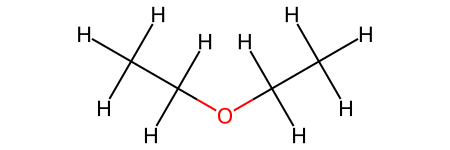

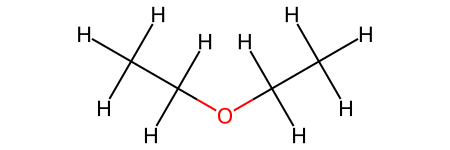


******************idx=2 mol.formula='H2-O-Cl3-Fe'******************

******************idx=3 mol.formula='H10-C4-O'******************
[array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True]), array([ True,  True,  True])]
C [9.3494897, 12.1903552, 15.2429643] C [ 9.3494897 12.1903552 15.2429643] [ True  True  True]
H [9.2503785, 11.6566577, 14.4151283] H [ 9.2503785 11.6566577 14.4151283] [ True  True  True]
H [10.314404, 12.2675314, 15.4508048] H [10.314404  12.2675314 15.4508048] [ True  True  True]
C [8.6286451, 11.513658000000001, 16.3827914] C [ 8.6286451 11.513658  16.3827914] [ True  True  True]
H [8.7108809, 12.0604495, 

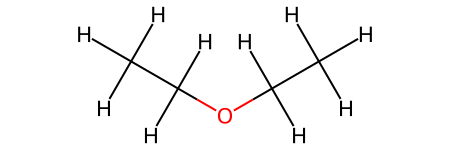

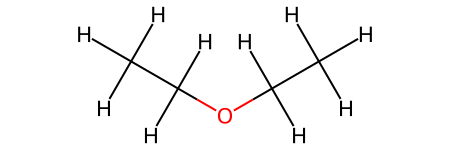


******************idx=4 mol.formula='H2-O-Cl3-Fe'******************

******************idx=5 mol.formula='H36-C16-N'******************

******************idx=6 mol.formula='H36-C16-N'******************

******************idx=7 mol.formula='H36-C16-N'******************

******************idx=8 mol.formula='H36-C16-N'******************



In [80]:
prepare_mols_v2(newcell.moleclist, newcell.unique_indices, newcell.unique_species, 
                  selected_cs, final_charge_distribution[0], debug=debug)

In [51]:
newcell.moleclist[1]

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 15
 Formula                      = H10-C4-O
 Has Adjacency Matrix         = YES
 Total Charge                 = 0
 Smiles                       = [H]C([H])([H])C([H])([H])OC([H])([H])C([H])([H])[H]
 Origin                       = cell.reconstruct
---------------------------------------------------

In [119]:
newcell.moleclist[3].create_bonds(debug=debug)

BUILD BONDS: atom 0 C
BUILD BONDS: bond 0 3 1.0 C O C
Error with Bond EndAtom O C
BUILD BONDS: bond 0 4 1.0 C C H
Error with Bond EndAtom C H
BUILD BONDS: bond 0 5 1.0 C H H
BUILD BONDS: bond 0 8 1.0 C H O
Error with Bond EndAtom H O
BUILD BONDS: atom 1 H
BUILD BONDS: bond 1 3 1.0 H O C
Error with Bond EndAtom O C
BUILD BONDS: atom 2 H
BUILD BONDS: bond 2 3 1.0 H O C
Error with Bond EndAtom O C
BUILD BONDS: atom 3 O
Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL: O C
BUILD BONDS: atom 4 C
Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL: C H
BUILD BONDS: atom 5 H
BUILD BONDS: bond 0 5 1.0 C H H
BUILD BONDS: atom 6 H
Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL: H C
BUILD BONDS: atom 7 C
BUILD BONDS: bond 6 7 1.0 H C C
BUILD BONDS: bond 7 8 1.0 C H O
Error with Bond EndAtom H O
BUILD BONDS: bond 7 11 1.0 C H H
BUILD BONDS: bond 7 13 1.0 C H H
BUILD BONDS: atom 8 H
Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL: H O


In [ ]:
def prepare_mols_test(moleclist: list, unique_indices: list, unique_species: list, 
                      selected_cs: list, final_charge_distribution: list, debug: int=0):
    # The charge and connectivity of a given specie in the unit cell is only determined for one representative case. i
    # For instance, if four molecules "A" are in the unit cell, only one is evaluated in the rest of the code. 
    # This function ensures that all other "A" molecules in the unit cell end up having the same interpretation (charge and connectivity).
    # In some cases, this might be a difficult job, since the connectivity (i.e. Lewis Structure) often depends on the atom ordering, which might change
    # Thus, an Hungarian ordering is implemented.
    
    Warning = False
    idxtoallocate = 0
 
    for idx, mol in enumerate(moleclist):
        #if hasattr(mol,"totcharge") and hasattr(mol,"rdkit_obj"): continue 
        if debug >= 2: print(f"******************{idx=} {mol.formula=}******************")
        ###################################
        ### FOR SOLVENT AND COUNTERIONS ###
        ###################################
        if mol.subtype == "molecule" and mol.iscomplex == False:
            spec = unique_species[mol.unique_index]   # This is the reference specie
            if debug >= 2: print(f"PREPARE: Doing molecule {idx} with unique_index: {mol.unique_index}")
            if debug >= 2: print(f"PREPARE: Specie with poscharges: {spec.possible_cs}")
    
            allocated = False
            for jdx, cs in enumerate(spec.possible_cs):
                # If the charge in poscharges coincides with the one for this entry in final_distribution
                if final_charge_distribution[idxtoallocate] == cs.corr_total_charge and not allocated:  

                    print("***1")
                    ## Reorders the atoms to increase chance of perfectly reproducing the desired charge
                    ref_data, target_data = arrange_data_for_reorder(spec, mol)
                    print(ref_data==target_data)
                    if debug >= 2: print(f"PREPARE: reordering with data: \n{ref_data=}\n{target_data=}")
                    dummy1, dummy2, map12 = reorder(ref_data, target_data, spec.coord, mol.coord)
                    if debug >= 2: print(f"PREPARE: reordering with {dummy1}")
                    if debug >= 2: print(f"PREPARE: reordering with {dummy2}")
                    if debug >= 2: print(f"PREPARE: reordering protonation with {map12}")
                    prot = cs.protonation.reorder(map12, debug=debug)
                    if debug >= 2: print(f"PREPARE: reordered protonation: \n{prot}")
                    ###############    

                    allocated = True 
                    idxtoallocate += 1
                    new_cs = get_charge(cs.corr_total_charge, prot, allow=cs.allow, debug=debug)
                    
                    if new_cs.corr_total_charge == cs.corr_total_charge:
                        for atom, atom_rd in zip(mol.atoms, new_cs.rdkit_obj.GetAtoms()):
                            print(atom.label, atom_rd.GetSymbol())
                        
                        mol.set_charges(new_cs.corr_total_charge, new_cs.corr_atom_charges, new_cs.smiles, new_cs.rdkit_obj)
                        
                        if debug >= 2: print(f"PREPARE: Success doing molecule {idx}. Created Charge State with total_charge={new_cs.corr_total_charge}") 
                    else:
                        if debug >= 2: print(f"PREPARE: Error doing molecule {idx}. Created Charge State is different than Target {new_cs.corr_total_charge} vs {cs.corr_total_charge}")
                        
                else :
                    print("0003")
                    
            if not allocated: Warning = False

In [ ]:
prepare_mols_test(newcell.moleclist, newcell.unique_indices, newcell.unique_species, 
                  selected_cs, final_charge_distribution[0], debug=debug)


In [ ]:
for mol in newcell.moleclist: 
    if not mol.iscomplex: 
        try :
            print(mol.protonation_states)
        except:
            pass
        for idx, (atom, atom_rd) in enumerate(zip(mol.atoms, mol.rdkit_obj.GetAtoms())):
            rdkitatom = mol.rdkit_obj.GetAtomWithIdx(idx) 
            tmp = rdkitatom.GetSymbol()
            print(atom.label, atom_rd.GetSymbol(), tmp, idx, atom_rd.GetIdx())
            for b in rdkitatom.GetBonds():
                bond_startatom = b.GetBeginAtomIdx()
                bond_endatom   = b.GetEndAtomIdx()
                bond_order     = b.GetBondTypeAsDouble()     
                print("BUILD BONDS: bond", bond_startatom, bond_endatom, bond_order)
            # For each atom, set the property "molAtomMapNumber" to a custom number, let's say, the index of the atom in the molecule
            atom_rd.SetProp("molAtomMapNumber", str(atom_rd.GetIdx()))
        display(mol.rdkit_obj, )
#         mol.create_bonds(debug=debug)     

In [ ]:
newcell

In [ ]:
newcell.error_prepare_mols

In [ ]:
newcell.create_bonds(debug=debug)

In [ ]:
from cell2mol.classes import *

In [ ]:
for mol in newcell.moleclist:
    if mol.iscomplex:
        print(mol.formula)
        for lig in mol.ligands:
            for idx, atom in enumerate(lig.atoms):
                # Security Check. Confirms that the labels are the same
                if debug >= 2: print("BUILD BONDS: atom", idx, atom.label)
                rdkitatom = lig.rdkit_obj.GetAtomWithIdx(idx)            
                tmp = rdkitatom.GetSymbol()

                if atom.label != tmp: 
                    print("Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL:", atom.label, tmp)
                else:
                    print(rdkitatom.GetBonds())
                    # First part. Creates bond information
                    for b in rdkitatom.GetBonds():
                        print(b)
                        bond_startatom = b.GetBeginAtomIdx()
                        bond_endatom   = b.GetEndAtomIdx()
                        bond_order     = b.GetBondTypeAsDouble()
                        
                        if debug >= 2: print("BUILD BONDS: bond", bond_startatom, bond_endatom, bond_order, 
                                             lig.atoms[bond_startatom].label, lig.atoms[bond_endatom].label, 
                                             lig.rdkit_obj.GetAtomWithIdx(bond_endatom).GetSymbol())
#                         if (lig.subtype == "ligand") and (bond_startatom >= lig.natoms or bond_endatom >= lig.natoms):
#                             continue
#                         else:
#                             if lig.atoms[bond_endatom].label != lig.rdkit_obj.GetAtomWithIdx(bond_endatom).GetSymbol():
#                                 if debug >= 1: 
#                                     print("Error with Bond EndAtom", 
#                                           lig.atoms[bond_endatom].label, lig.rdkit_obj.GetAtomWithIdx(bond_endatom).GetSymbol())
#                             else:
#                                 if bond_endatom == idx:
#                                     start = bond_endatom
#                                     end   = bond_startatom
#                                 elif bond_startatom == idx:
#                                     start = bond_startatom
#                                     end   = bond_endatom

#                                 ## This has changed. Now there is a bond object, and we send the atom objects, not only the index
#                                 new_bond = bond(lig.atoms[start], lig.atoms[end], bond_order) 
#                                 atom.add_bond(new_bond)
#                                 print(new_bond)

In [ ]:
met1.check_connectivity(met2, debug=debug)

In [ ]:
met1.radii